In [1]:
import pandas as pd

# Read the dataset
df = pd.read_csv('SEER.csv')

# Select only the required features
features = ['Age with single ages and 100+', 'Year of diagnosis', 'Sex', 'Race', 'Ethnicity', 'Marital status at diagnosis', 
            'Primary Site', 'Grade ', 'Summary Stage (2004+)', 'Appalachia', 'Survival recode']
df = df[features]

# Display the first few rows of the dataset
print("Initial DataFrame:")
df.head()


Initial DataFrame:


,Age with single ages and 100+,Year of diagnosis,Sex,Race,Ethnicity,Marital status at diagnosis,Primary Site,Grade,Summary Stage (2004+),Appalachia,Survival recode
0,66,2013,0,1,0,1,18.0,2,1,0,1
1,70,2010,0,0,0,1,18.7,2,1,0,0
2,48,2001,0,0,0,1,18.7,2,99,0,1
3,54,2006,0,1,0,1,18.2,3,3,0,0
4,88,2009,1,0,0,0,18.0,2,3,0,0


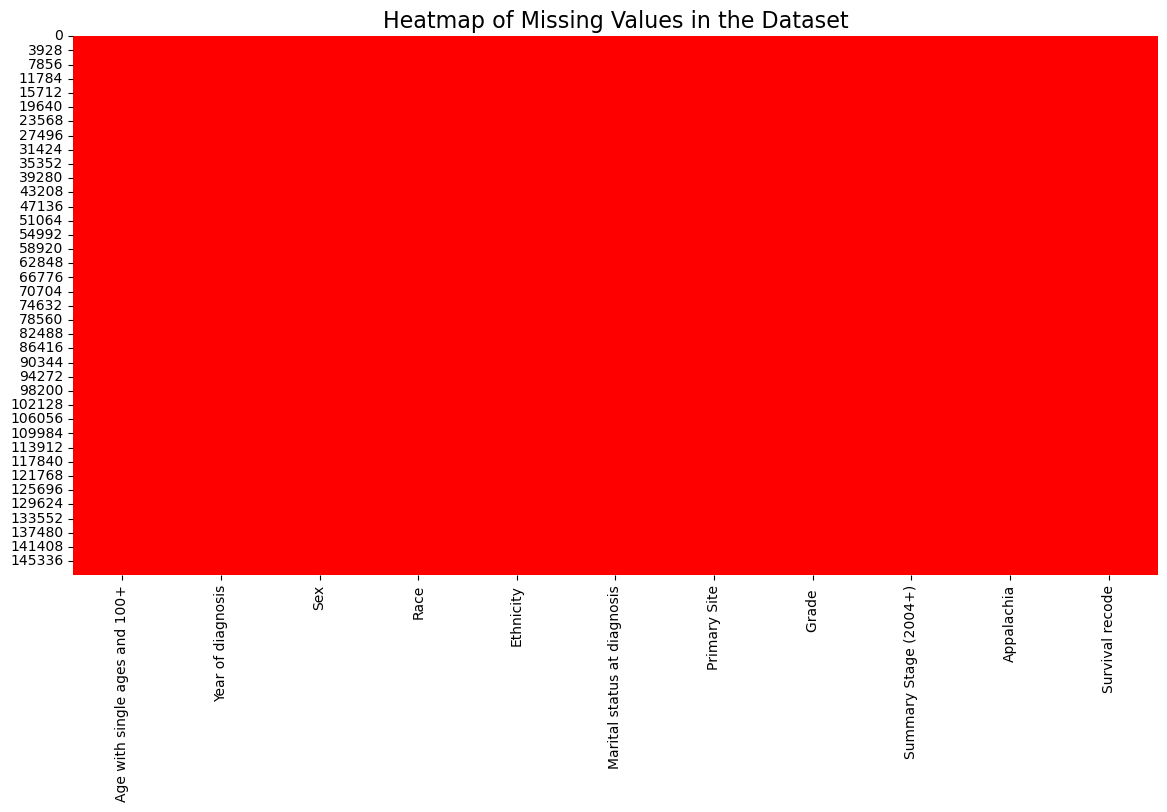

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizing missing values in the dataset
plt.figure(figsize=(14, 7))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', linewidths=0.5, linecolor='red')
plt.title('Heatmap of Missing Values in the Dataset', fontsize=16)
plt.show()


In [3]:
# Convert categorical variables to numeric
df = pd.get_dummies(df, columns=['Sex', 'Race', 'Ethnicity', 'Marital status at diagnosis', 'Primary Site', 'Grade ', 'Summary Stage (2004+)'])

# Display the updated DataFrame
print("DataFrame after converting categorical variables to numeric:")
df.head()


DataFrame after converting categorical variables to numeric:


,Age with single ages and 100+,Year of diagnosis,Appalachia,Survival recode,Sex_0,Sex_1,Race_0,Race_1,Race_2,Race_3,...,Grade _1,Grade _2,Grade _3,Grade _4,Grade _99,Grade _T-cell,Summary Stage (2004+)_1,Summary Stage (2004+)_2,Summary Stage (2004+)_3,Summary Stage (2004+)_99
0,66,2013,0,1,True,False,False,True,False,False,...,False,True,False,False,False,False,True,False,False,False
1,70,2010,0,0,True,False,True,False,False,False,...,False,True,False,False,False,False,True,False,False,False
2,48,2001,0,1,True,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,54,2006,0,0,True,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
4,88,2009,0,0,False,True,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False


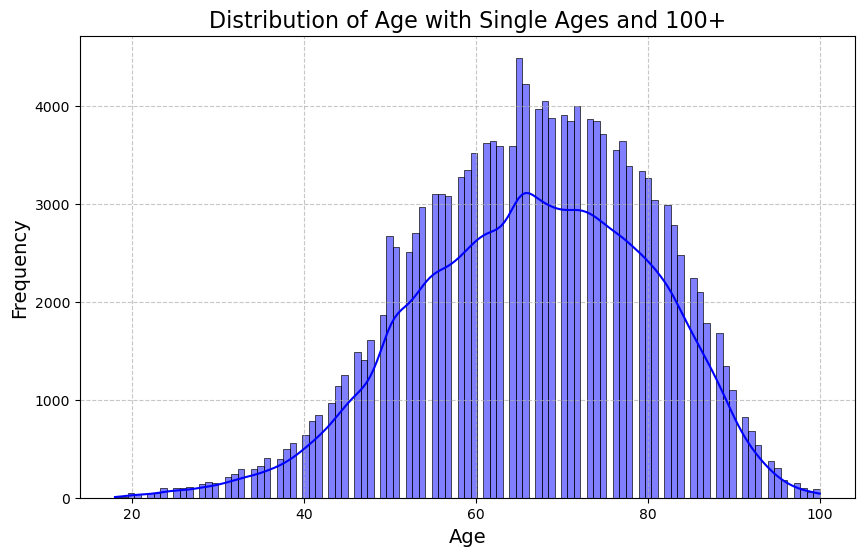

In [4]:
# Distribution of Age with Single Ages and 100+
plt.figure(figsize=(10, 6))
sns.histplot(df['Age with single ages and 100+'], kde=True, color='blue')
plt.title('Distribution of Age with Single Ages and 100+', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [5]:
# Check for missing values in the dataset
print("Missing values in the dataset:")
print(df.isnull().sum())

# Drop rows with missing values
df = df.dropna()

# Verify that there are no more missing values
print("Missing values after dropping rows:")
df.isnull().sum()


Missing values in the dataset:
Age with single ages and 100+     0
Year of diagnosis                 0
Appalachia                        0
Survival recode                   0
Sex_0                             0
Sex_1                             0
Race_0                            0
Race_1                            0
Race_2                            0
Race_3                            0
Race_99                           0
Ethnicity_0                       0
Ethnicity_1                       0
Marital status at diagnosis_0     0
Marital status at diagnosis_1     0
Marital status at diagnosis_99    0
Primary Site_18.0                 0
Primary Site_18.1                 0
Primary Site_18.2                 0
Primary Site_18.3                 0
Primary Site_18.4                 0
Primary Site_18.5                 0
Primary Site_18.6                 0
Primary Site_18.7                 0
Primary Site_18.8                 0
Primary Site_18.9                 0
Primary Site_19.9                

Age with single ages and 100+     0
Year of diagnosis                 0
Appalachia                        0
Survival recode                   0
Sex_0                             0
Sex_1                             0
Race_0                            0
Race_1                            0
Race_2                            0
Race_3                            0
Race_99                           0
Ethnicity_0                       0
Ethnicity_1                       0
Marital status at diagnosis_0     0
Marital status at diagnosis_1     0
Marital status at diagnosis_99    0
Primary Site_18.0                 0
Primary Site_18.1                 0
Primary Site_18.2                 0
Primary Site_18.3                 0
Primary Site_18.4                 0
Primary Site_18.5                 0
Primary Site_18.6                 0
Primary Site_18.7                 0
Primary Site_18.8                 0
Primary Site_18.9                 0
Primary Site_19.9                 0
Grade _0                    

In [6]:
# Filter out unexpected classes from the target variable
df = df[df['Survival recode'].isin([0, 1, 2])]

# Display the first few rows of the filtered dataset
print("Filtered DataFrame:")
df.head()


Filtered DataFrame:


,Age with single ages and 100+,Year of diagnosis,Appalachia,Survival recode,Sex_0,Sex_1,Race_0,Race_1,Race_2,Race_3,...,Grade _1,Grade _2,Grade _3,Grade _4,Grade _99,Grade _T-cell,Summary Stage (2004+)_1,Summary Stage (2004+)_2,Summary Stage (2004+)_3,Summary Stage (2004+)_99
0,66,2013,0,1,True,False,False,True,False,False,...,False,True,False,False,False,False,True,False,False,False
1,70,2010,0,0,True,False,True,False,False,False,...,False,True,False,False,False,False,True,False,False,False
2,48,2001,0,1,True,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,54,2006,0,0,True,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
4,88,2009,0,0,False,True,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False


C:\Users\kalya\AppData\Local\Temp\ipykernel_24744\3640924462.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df, palette='viridis')


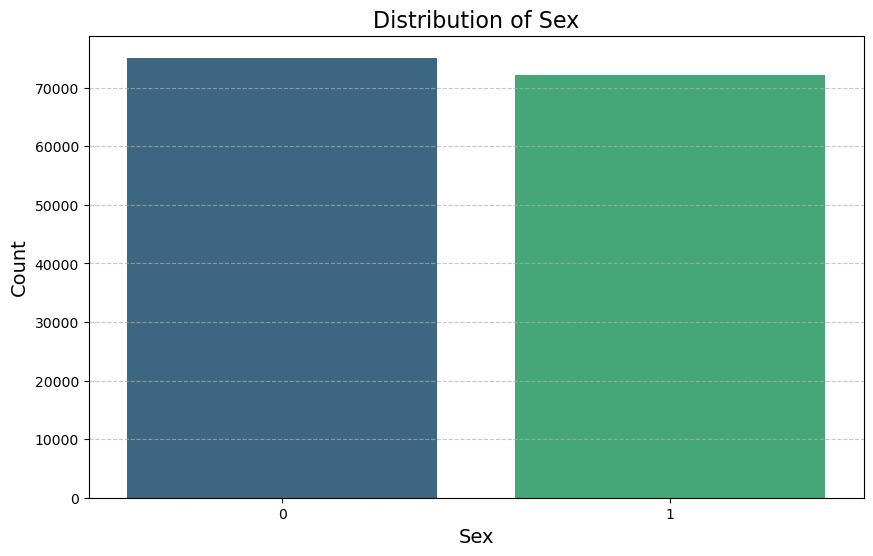

C:\Users\kalya\AppData\Local\Temp\ipykernel_24744\3640924462.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Race', data=df, palette='viridis')


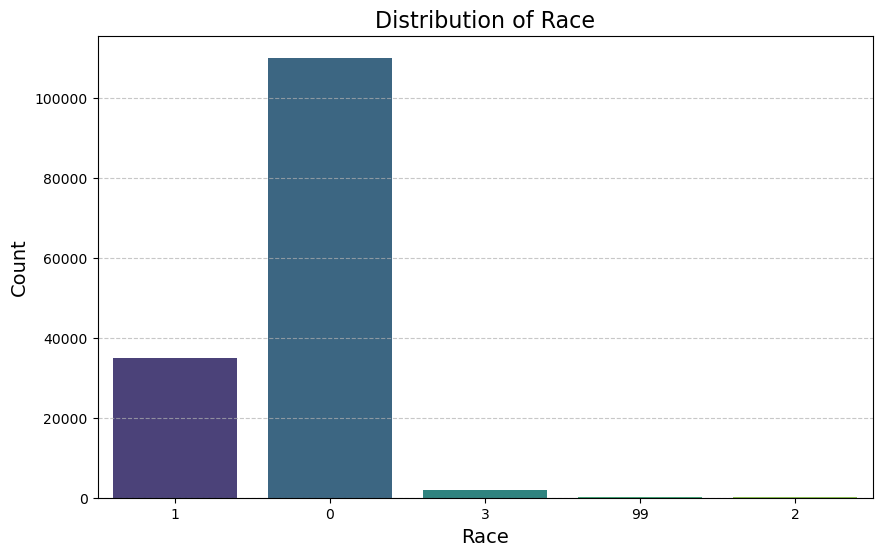

In [7]:
# Combine dummy variables to a single categorical column for visualization
df['Sex'] = df[['Sex_0', 'Sex_1']].idxmax(axis=1).str.replace('Sex_', '')
df['Race'] = df[['Race_0', 'Race_1', 'Race_2', 'Race_3', 'Race_99']].idxmax(axis=1).str.replace('Race_', '')

# Distribution of Sex
plt.figure(figsize=(10, 6))
sns.countplot(x='Sex', data=df, palette='viridis')
plt.title('Distribution of Sex', fontsize=16)
plt.xlabel('Sex', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Distribution of Race
plt.figure(figsize=(10, 6))
sns.countplot(x='Race', data=df, palette='viridis')
plt.title('Distribution of Race', fontsize=16)
plt.xlabel('Race', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [8]:
# Divide the dataset into two parts
data_A = df[df['Appalachia'] == 1]
data_NA = df[df['Appalachia'] == 0]

# Drop the 'Appalachia' column as it's no longer needed
data_A = data_A.drop(columns=['Appalachia'])
data_NA = data_NA.drop(columns=['Appalachia'])

# Display the first few rows of each subset
print("\nData for Appalachia (data_A):")
print(data_A.head())
print("\nData for Non-Appalachia (data_NA):")
data_NA.head()



Data for Appalachia (data_A):
       Age with single ages and 100+  Year of diagnosis  Survival recode  \
81515                             57               2005                0   
81516                             76               2009                1   
81517                             61               2014                0   
81518                             75               2004                1   
81519                             88               2001                0   

       Sex_0  Sex_1  Race_0  Race_1  Race_2  Race_3  Race_99  ...  Grade _3  \
81515   True  False    True   False   False   False    False  ...      True   
81516   True  False    True   False   False   False    False  ...     False   
81517  False   True    True   False   False   False    False  ...     False   
81518   True  False    True   False   False   False    False  ...     False   
81519   True  False    True   False   False   False    False  ...     False   

       Grade _4  Grade _99  Grade _T-

,Age with single ages and 100+,Year of diagnosis,Survival recode,Sex_0,Sex_1,Race_0,Race_1,Race_2,Race_3,Race_99,...,Grade _3,Grade _4,Grade _99,Grade _T-cell,Summary Stage (2004+)_1,Summary Stage (2004+)_2,Summary Stage (2004+)_3,Summary Stage (2004+)_99,Sex,Race
0,66,2013,1,True,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,0,1
1,70,2010,0,True,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,0,0
2,48,2001,1,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,0,0
3,54,2006,0,True,False,False,True,False,False,False,...,True,False,False,False,False,False,True,False,0,1
4,88,2009,0,False,True,True,False,False,False,False,...,False,False,False,False,False,False,True,False,1,0


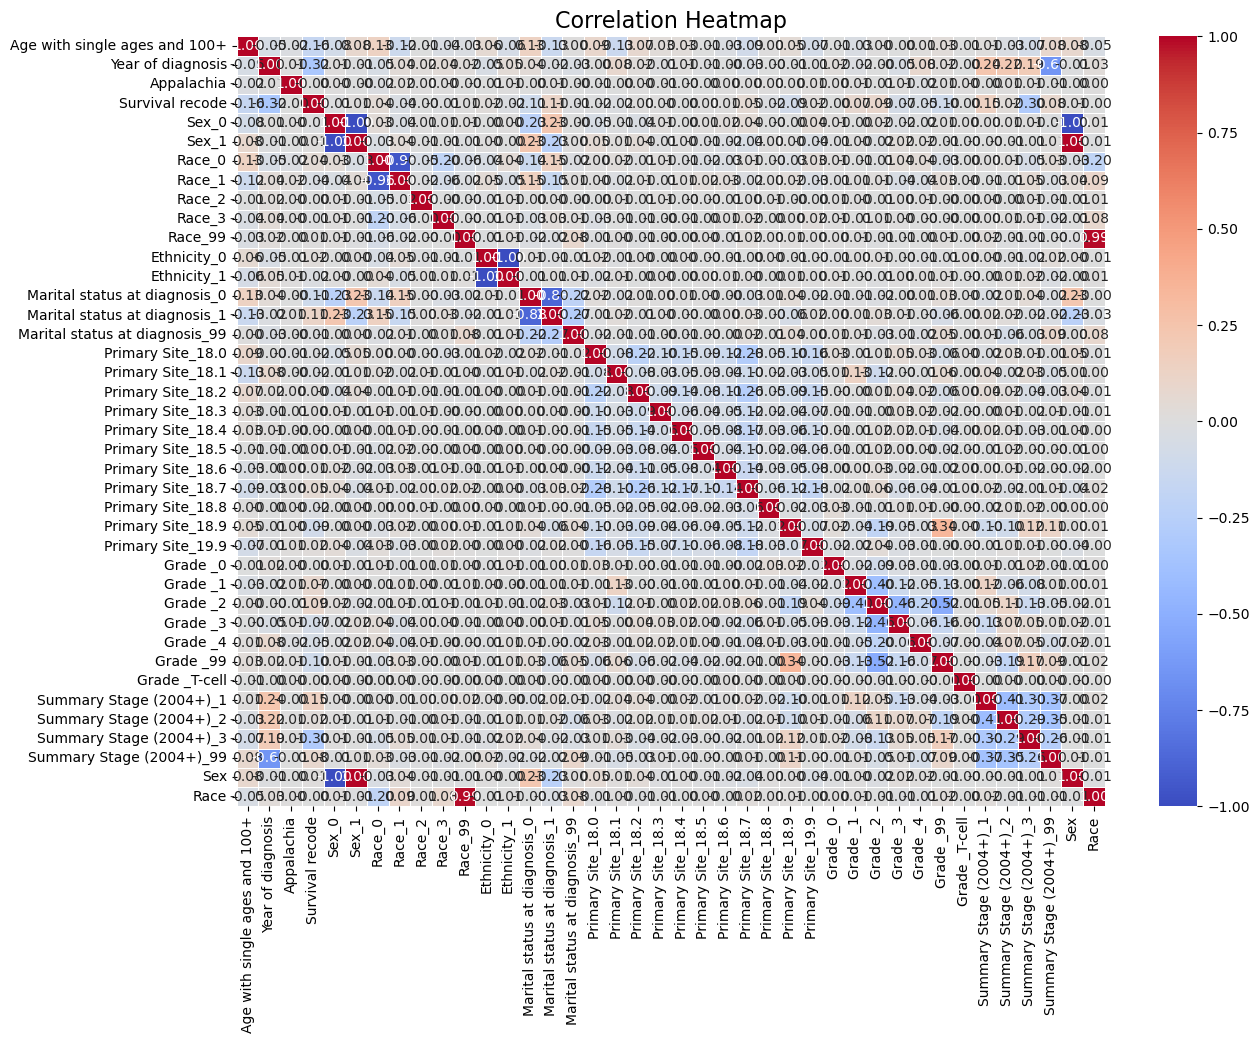

In [9]:
# Correlation matrix heatmap
plt.figure(figsize=(14, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, linecolor='white')
plt.title('Correlation Heatmap', fontsize=16)
plt.show()


In [10]:
# Define the target variable
y_A = data_A['Survival recode']
y_NA = data_NA['Survival recode']

# Drop target variable from feature datasets
X_A = data_A.drop(columns=['Survival recode'])
X_NA = data_NA.drop(columns=['Survival recode'])

from sklearn.preprocessing import StandardScaler

# Standardize the dataset
scaler = StandardScaler()
X_A_scaled = scaler.fit_transform(X_A)
X_NA_scaled = scaler.fit_transform(X_NA)

# Display the standardized data
print("\nStandardized data for Appalachia (data_A_scaled):")
print(X_A_scaled[:5])
print("\nStandardized data for Non-Appalachia (data_NA_scaled):")
print(X_NA_scaled[:5])



Standardized data for Appalachia (data_A_scaled):
[[-0.6691996  -0.71265716  0.97558425 -0.97558425  0.5952787  -0.57142148
  -0.02764053 -0.11718758 -0.03440852  0.13797416 -0.13797416 -0.84490921
   0.95546989 -0.25424099 -0.4860655  -0.16588039  2.17970621 -0.20451373
  -0.30404241 -0.17413    -0.25337232 -0.56713424 -0.1011061  -0.20759263
  -0.33131995 -0.07088545 -0.32614837 -1.23056972  2.65422646 -0.14837285
  -0.42105147 -0.01223568 -0.65496867  1.6057969  -0.46614619 -0.56480588
  -0.97558425 -0.11802865]
 [ 0.73336789  0.05569566  0.97558425 -0.97558425  0.5952787  -0.57142148
  -0.02764053 -0.11718758 -0.03440852  0.13797416 -0.13797416  1.18355912
  -1.04660545 -0.25424099  2.0573359  -0.16588039 -0.45877742 -0.20451373
  -0.30404241 -0.17413    -0.25337232 -0.56713424 -0.1011061  -0.20759263
  -0.33131995 -0.07088545 -0.32614837  0.81263173 -0.3767576  -0.14837285
  -0.42105147 -0.01223568 -0.65496867  1.6057969  -0.46614619 -0.56480588
  -0.97558425 -0.11802865]
 [-0.37

In [11]:
from sklearn.model_selection import train_test_split

# Split data_A into train, test, validate
train_A, temp_A, y_train_A, y_temp_A = train_test_split(X_A_scaled, y_A, test_size=0.3, random_state=42)
test_A, validate_A, y_test_A, y_validate_A = train_test_split(temp_A, y_temp_A, test_size=0.33, random_state=42) # 0.33 * 0.3 = ~10%

# Split data_NA into train, test, validate
train_NA, temp_NA, y_train_NA, y_temp_NA = train_test_split(X_NA_scaled, y_NA, test_size=0.3, random_state=42)
test_NA, validate_NA, y_test_NA, y_validate_NA = train_test_split(temp_NA, y_temp_NA, test_size=0.33, random_state=42)

# Display the splits
print("\nTrain data for Appalachia (train_A):")
print(train_A[:5])
print("\nTest data for Appalachia (test_A):")
print(test_A[:5])
print("\nValidate data for Appalachia (validate_A):")
print(validate_A[:5])

print("\nTrain data for Non-Appalachia (train_NA):")
print(train_NA[:5])
print("\nTest data for Non-Appalachia (test_NA):")
print(test_NA[:5])
print("\nValidate data for Non-Appalachia (validate_NA):")
print(validate_NA[:5])



Train data for Appalachia (train_A):
[[ 0.2166325   1.40031309 -1.02502679  1.02502679  0.5952787  -0.57142148
  -0.02764053 -0.11718758 -0.03440852  0.13797416 -0.13797416 -0.84490921
   0.95546989 -0.25424099 -0.4860655  -0.16588039 -0.45877742 -0.20451373
  -0.30404241  5.74283578 -0.25337232 -0.56713424 -0.1011061  -0.20759263
  -0.33131995 -0.07088545 -0.32614837  0.81263173 -0.3767576  -0.14837285
  -0.42105147 -0.01223568  1.52679059 -0.62274376 -0.46614619 -0.56480588
   1.02502679 -0.11802865]
 [ 0.06899382  0.43987207 -1.02502679  1.02502679 -1.67988541  1.75002172
  -0.02764053 -0.11718758 -0.03440852  0.13797416 -0.13797416  1.18355912
  -1.04660545 -0.25424099 -0.4860655  -0.16588039  2.17970621 -0.20451373
  -0.30404241 -0.17413    -0.25337232 -0.56713424 -0.1011061  -0.20759263
  -0.33131995 -0.07088545 -0.32614837  0.81263173 -0.3767576  -0.14837285
  -0.42105147 -0.01223568 -0.65496867 -0.62274376  2.14524974 -0.56480588
   1.02502679  0.1731206 ]
 [-0.37392223  0.247

In [12]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression with different solvers
solvers = ['newton-cg', 'liblinear', 'lbfgs']
models_A = {}
models_NA = {}

for solver in solvers:
    model_A = LogisticRegression(solver=solver)
    model_A.fit(train_A, y_train_A)
    models_A[solver] = model_A
    
    model_NA = LogisticRegression(solver=solver)
    model_NA.fit(train_NA, y_train_NA)
    models_NA[solver] = model_NA

    # Print model coefficients for each solver
    print(f'\nLogistic Regression (Solver: {solver}) - Appalachia Coefficients:')
    print(model_A.coef_)
    print(f'\nLogistic Regression (Solver: {solver}) - Non-Appalachia Coefficients:')
    print(model_NA.coef_)



Logistic Regression (Solver: newton-cg) - Appalachia Coefficients:
[[-5.17643599e-01 -1.36294839e+00 -3.42549682e-02  3.42549682e-02
   4.14406321e-02 -4.22453863e-02  2.52717565e-02 -7.85731271e-03
   5.64084254e-03  1.93791838e-02 -1.93791838e-02 -8.52364375e-02
   9.94893561e-02 -3.21308815e-02  5.44832697e-03 -2.65163982e-02
   2.54970303e-02  1.27150388e-03  3.03376514e-03 -5.28473753e-03
  -8.79800112e-03  2.12160587e-02 -3.11166989e-02 -7.47932290e-02
   1.09336530e-02  4.07496509e-02  8.37639824e-02  6.92252155e-02
  -1.35301195e-01 -2.73789783e-02 -3.54018893e-02 -1.40758889e-02
   5.78729277e-01  3.55485898e-01 -6.42451009e-01 -4.17451040e-01
   3.42549682e-02 -9.73437817e-05]]

Logistic Regression (Solver: newton-cg) - Non-Appalachia Coefficients:
[[-0.53966806 -1.35033442 -0.04140536  0.04140536  0.04464949 -0.04673598
   0.00566372  0.00189473  0.00296328  0.02197681 -0.02197681 -0.08544285
   0.09990462 -0.03197737  0.01054772 -0.03710706  0.01822301  0.0101966
  -0.0033

In [13]:
from xgboost import XGBClassifier

# Default XGBoost model
xgb_model_A_default = XGBClassifier()
xgb_model_A_default.fit(train_A, y_train_A)
print("\nDefault XGBoost model for Appalachia - Feature Importances:")
print(xgb_model_A_default.feature_importances_)

xgb_model_NA_default = XGBClassifier()
xgb_model_NA_default.fit(train_NA, y_train_NA)
print("\nDefault XGBoost model for Non-Appalachia - Feature Importances:")
print(xgb_model_NA_default.feature_importances_)

# Hyperparameterized XGBoost model
xgb_model_A_hyper = XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=100)
xgb_model_A_hyper.fit(train_A, y_train_A)
print("\nHyperparameterized XGBoost model for Appalachia - Feature Importances:")
print(xgb_model_A_hyper.feature_importances_)

xgb_model_NA_hyper = XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=100)
xgb_model_NA_hyper.fit(train_NA, y_train_NA)
print("\nHyperparameterized XGBoost model for Non-Appalachia - Feature Importances:")
print(xgb_model_NA_hyper.feature_importances_)



Default XGBoost model for Appalachia - Feature Importances:
[0.02267129 0.11274447 0.00862495 0.         0.0058292  0.01138958
 0.00224611 0.00463238 0.0042194  0.00666301 0.         0.00657721
 0.01899271 0.00636166 0.00657949 0.01025751 0.00688912 0.00517127
 0.00523316 0.0045935  0.00619985 0.00633423 0.00548692 0.01587788
 0.00619568 0.01026618 0.02089353 0.01126193 0.01583767 0.0065668
 0.01387559 0.00237567 0.05419963 0.00635059 0.515493   0.04806564
 0.         0.00504315]

Default XGBoost model for Non-Appalachia - Feature Importances:
[0.02492468 0.12891476 0.01021846 0.         0.00602178 0.01220389
 0.00192499 0.00459344 0.00669298 0.00823208 0.         0.00857236
 0.01463741 0.00629471 0.00528312 0.00935588 0.00653622 0.00588926
 0.00500528 0.00533901 0.00619647 0.00652799 0.00637159 0.01776974
 0.00496191 0.01101244 0.01663502 0.01322082 0.01714816 0.00585565
 0.02097783 0.00209863 0.07240227 0.00449567 0.47050598 0.04840215
 0.         0.00477728]

Hyperparameterized XGB

In [14]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Function to evaluate and print the confusion matrix and accuracy
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Confusion Matrix:\n{cm}\nAccuracy: {accuracy}')

for solver in solvers:
    print(f'\nLogistic Regression (Solver: {solver}) - Appalachia')
    evaluate_model(models_A[solver], test_A, y_test_A)
    
    print(f'\nLogistic Regression (Solver: {solver}) - Non-Appalachia')
    evaluate_model(models_NA[solver], test_NA, y_test_NA)
    
print('\nXGBoost (Default) - Appalachia')
evaluate_model(xgb_model_A_default, test_A, y_test_A)

print('\nXGBoost (Default) - Non-Appalachia')
evaluate_model(xgb_model_NA_default, test_NA, y_test_NA)

print('\nXGBoost (Hyperparameterized) - Appalachia')
evaluate_model(xgb_model_A_hyper, test_A, y_test_A)

print('\nXGBoost (Hyperparameterized) - Non-Appalachia')
evaluate_model(xgb_model_NA_hyper, test_NA, y_test_NA)



Logistic Regression (Solver: newton-cg) - Appalachia
Confusion Matrix:
[[6641 1627]
 [1834 3326]]
Accuracy: 0.7422549895740245

Logistic Regression (Solver: newton-cg) - Non-Appalachia
Confusion Matrix:
[[7945 1919]
 [2358 3960]]
Accuracy: 0.735693980966506

Logistic Regression (Solver: liblinear) - Appalachia
Confusion Matrix:
[[6641 1627]
 [1833 3327]]
Accuracy: 0.7423294608281203

Logistic Regression (Solver: liblinear) - Non-Appalachia
Confusion Matrix:
[[7945 1919]
 [2359 3959]]
Accuracy: 0.735632183908046

Logistic Regression (Solver: lbfgs) - Appalachia
Confusion Matrix:
[[6642 1626]
 [1836 3324]]
Accuracy: 0.7421805183199285

Logistic Regression (Solver: lbfgs) - Non-Appalachia
Confusion Matrix:
[[7944 1920]
 [2359 3959]]
Accuracy: 0.735570386849586

XGBoost (Default) - Appalachia
Confusion Matrix:
[[6406 1862]
 [1149 4011]]
Accuracy: 0.7757670539171879

XGBoost (Default) - Non-Appalachia
Confusion Matrix:
[[7664 2200]
 [1390 4928]]
Accuracy: 0.7781485601285378

XGBoost (Hyper

In [15]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Define the hyperparameter grid
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [50, 100, 200]
}

# Perform grid search for Appalachia data
grid_search_A = GridSearchCV(estimator=XGBClassifier(), param_grid=param_grid, cv=5, scoring='accuracy')
grid_search_A.fit(train_A, y_train_A)
best_model_A = grid_search_A.best_estimator_
print("\nBest Hyperparameters for Appalachia:")
print(grid_search_A.best_params_)

# Perform grid search for Non-Appalachia data
grid_search_NA = GridSearchCV(estimator=XGBClassifier(), param_grid=param_grid, cv=5, scoring='accuracy')
grid_search_NA.fit(train_NA, y_train_NA)
best_model_NA = grid_search_NA.best_estimator_
print("\nBest Hyperparameters for Non-Appalachia:")
print(grid_search_NA.best_params_)



Best Hyperparameters for Appalachia:
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 50}

Best Hyperparameters for Non-Appalachia:
{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50}


In [16]:
# Evaluate the best models
print('\nBest XGBoost Model (Hyperparameterized) - Appalachia')
evaluate_model(best_model_A, test_A, y_test_A)

print('\nBest XGBoost Model (Hyperparameterized) - Non-Appalachia')
evaluate_model(best_model_NA, test_NA, y_test_NA)



Best XGBoost Model (Hyperparameterized) - Appalachia
Confusion Matrix:
[[6408 1860]
 [1058 4102]]
Accuracy: 0.7826928805481085

Best XGBoost Model (Hyperparameterized) - Non-Appalachia
Confusion Matrix:
[[7656 2208]
 [1330 4988]]
Accuracy: 0.7813620071684588


In [17]:
from sklearn.metrics import recall_score, precision_score, accuracy_score

# Function to compute ML metrics
def compute_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    tpr = recall_score(y_test, y_pred, pos_label=1)  # True Positive Rate
    tnr = recall_score(y_test, y_pred, pos_label=0)  # True Negative Rate
    ppv = precision_score(y_test, y_pred, pos_label=1)  # Positive Predictive Value
    npv = precision_score(y_test, y_pred, pos_label=0)  # Negative Predictive Value
    accuracy = accuracy_score(y_test, y_pred)
    print(f'TPR: {tpr}, TNR: {tnr}, PPV: {ppv}, NPV: {npv}, Accuracy: {accuracy}')

# Compute metrics for the best XGBoost models
print('\nMetrics for Best XGBoost Model (Hyperparameterized) - Appalachia')
compute_metrics(best_model_A, test_A, y_test_A)

print('\nMetrics for Best XGBoost Model (Hyperparameterized) - Non-Appalachia')
compute_metrics(best_model_NA, test_NA, y_test_NA)



Metrics for Best XGBoost Model (Hyperparameterized) - Appalachia
TPR: 0.7949612403100775, TNR: 0.7750362844702468, PPV: 0.6880241529688024, NPV: 0.8582909188320386, Accuracy: 0.7826928805481085

Metrics for Best XGBoost Model (Hyperparameterized) - Non-Appalachia
TPR: 0.7894903450459007, TNR: 0.7761557177615572, PPV: 0.6931628682601445, NPV: 0.8519919875361673, Accuracy: 0.7813620071684588


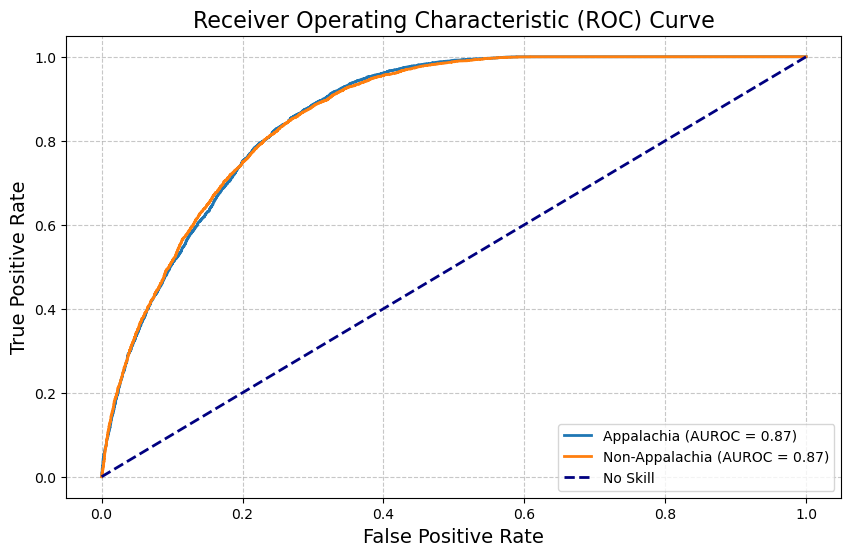

In [18]:
from sklearn.metrics import roc_curve, auc

# Function to plot ROC curve
def plot_roc_curve(model, X_test, y_test, label):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} (AUROC = {roc_auc:.2f})', lw=2)
    return roc_auc

# Plotting ROC curves
plt.figure(figsize=(10, 6))
roc_auc_appalachia = plot_roc_curve(best_model_A, test_A, y_test_A, 'Appalachia')
roc_auc_non_appalachia = plot_roc_curve(best_model_NA, test_NA, y_test_NA, 'Non-Appalachia')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='No Skill', lw=2)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [19]:
# Validate the best XGBoost models using validation data
print('\nValidation Metrics for Best XGBoost Model (Hyperparameterized) - Appalachia')
compute_metrics(best_model_A, validate_A, y_validate_A)

print('\nValidation Metrics for Best XGBoost Model (Hyperparameterized) - Non-Appalachia')
compute_metrics(best_model_NA, validate_NA, y_validate_NA)



Validation Metrics for Best XGBoost Model (Hyperparameterized) - Appalachia
TPR: 0.7999194847020934, TNR: 0.774818401937046, PPV: 0.6811792937949949, NPV: 0.8655666756829862, Accuracy: 0.7842455397641367

Validation Metrics for Best XGBoost Model (Hyperparameterized) - Non-Appalachia
TPR: 0.7905405405405406, TNR: 0.7949825210775242, PPV: 0.7113491603937464, NPV: 0.8558777949966793, Accuracy: 0.7932505331827876


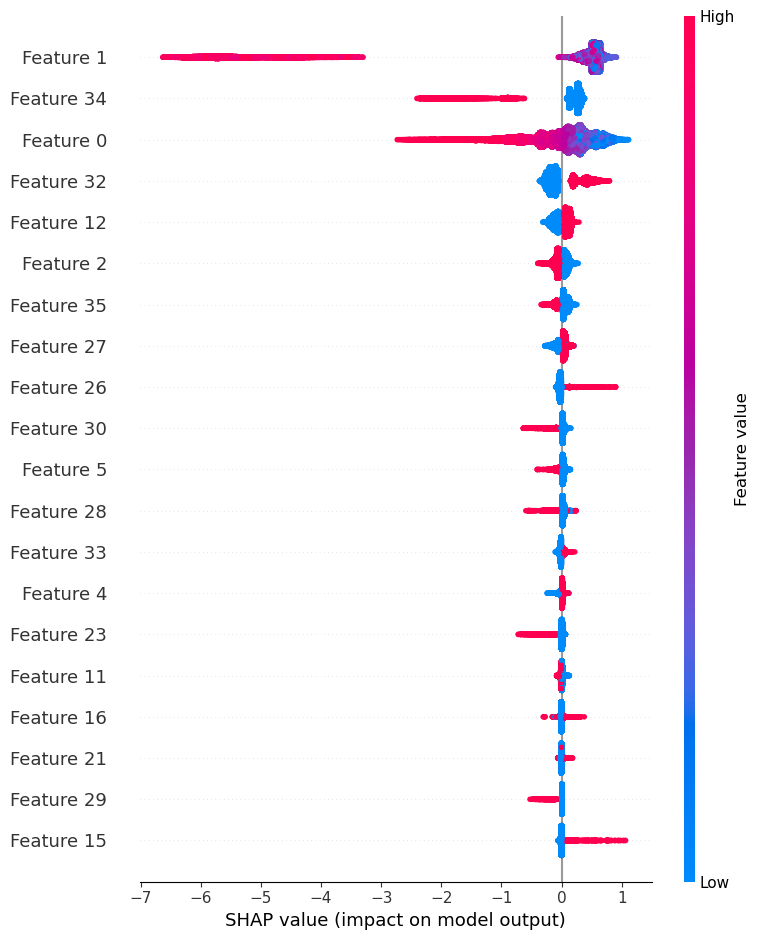

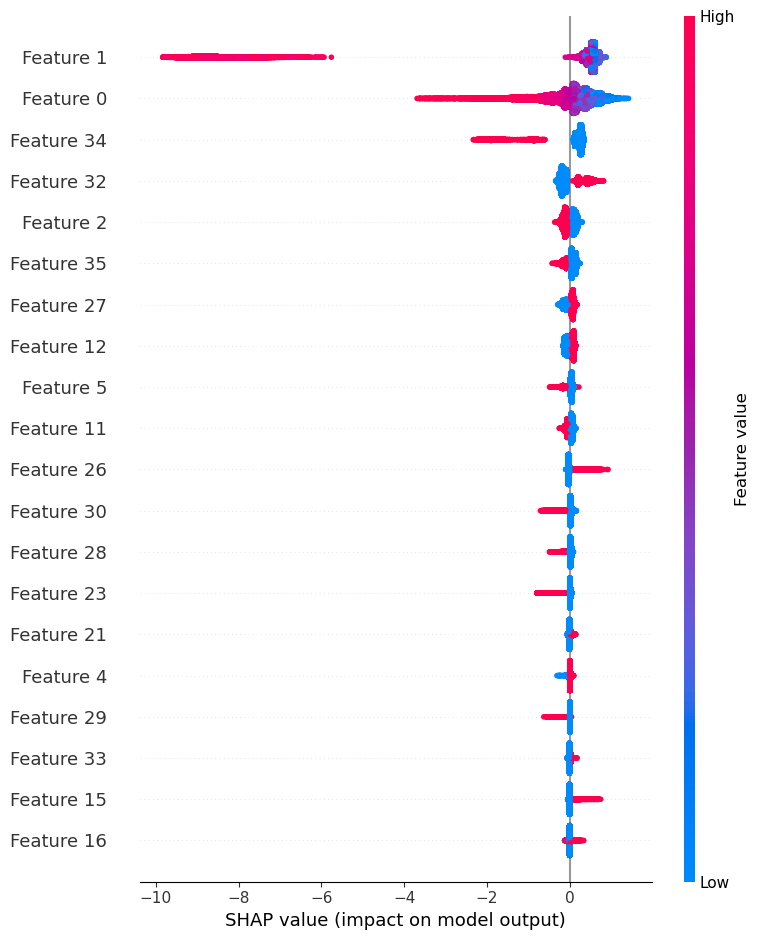

In [20]:
import shap

# Initialize JS visualization for SHAP
shap.initjs()

# Explain the model's predictions using SHAP
explainer_A = shap.Explainer(best_model_A)
shap_values_A = explainer_A(train_A)

# Plot SHAP summary plot for Appalachia
shap.summary_plot(shap_values_A, train_A)

# Explain the model's predictions using SHAP for Non-Appalachia
explainer_NA = shap.Explainer(best_model_NA)
shap_values_NA = explainer_NA(train_NA)

# Plot SHAP summary plot for Non-Appalachia
shap.summary_plot(shap_values_NA, train_NA)


In [21]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import shap

# Correct column names based on available columns in the dataset
features_extra = [
    'Year of diagnosis', 'Sex', 'Race', 'Ethnicity', 'Marital status at diagnosis', 'Primary Site', 'Grade',
    'Summary Stage (2004+)', 'Radiation', 'Chemotherapy', 'Appalachia', 'Survival recode'
]

# Read the dataset and select the required features
df_extra = pd.read_csv('SEER.csv')
df_extra.columns = df_extra.columns.str.strip()  # Ensure no leading/trailing whitespace
df_extra = df_extra[features_extra]



In [22]:
# Filter out unexpected classes from the target variable
df_extra = df_extra[df_extra['Survival recode'].isin([0, 1, 2])]

# Convert categorical variables to numeric
df_extra = pd.get_dummies(df_extra, columns=['Sex', 'Race', 'Ethnicity', 'Marital status at diagnosis', 'Primary Site', 'Grade', 'Summary Stage (2004+)', 'Radiation', 'Chemotherapy'])

# Drop rows with missing values
df_extra = df_extra.dropna()

In [23]:
# Divide the dataset into two parts
data_A_extra = df_extra[df_extra['Appalachia'] == 1]
data_NA_extra = df_extra[df_extra['Appalachia'] == 0]

# Drop the 'Appalachia' column as it's no longer needed
data_A_extra = data_A_extra.drop(columns=['Appalachia'])
data_NA_extra = data_NA_extra.drop(columns=['Appalachia'])

In [24]:
# Define the target variable
y_A_extra = data_A_extra['Survival recode']
y_NA_extra = data_NA_extra['Survival recode']

# Drop target variable from feature datasets
X_A_extra = data_A_extra.drop(columns=['Survival recode'])
X_NA_extra = data_NA_extra.drop(columns=['Survival recode'])

In [25]:
# Standardize the dataset
scaler = StandardScaler()
X_A_extra_scaled = scaler.fit_transform(X_A_extra)
X_NA_extra_scaled = scaler.fit_transform(X_NA_extra)

In [26]:
# Split data_A_extra into train, test, validate
train_A_extra, temp_A_extra, y_train_A_extra, y_temp_A_extra = train_test_split(X_A_extra_scaled, y_A_extra, test_size=0.3, random_state=42)
test_A_extra, validate_A_extra, y_test_A_extra, y_validate_A_extra = train_test_split(temp_A_extra, y_temp_A_extra, test_size=0.33, random_state=42)  # 0.33 * 0.3 = ~10%

# Split data_NA_extra into train, test, validate
train_NA_extra, temp_NA_extra, y_train_NA_extra, y_temp_NA_extra = train_test_split(X_NA_extra_scaled, y_NA_extra, test_size=0.3, random_state=42)
test_NA_extra, validate_NA_extra, y_test_NA_extra, y_validate_NA_extra = train_test_split(temp_NA_extra, y_temp_NA_extra, test_size=0.33, random_state=42)


In [27]:
# Hyperparameterized XGBoost model for extra credit
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [50, 100, 200]
}
grid_search_A_extra = GridSearchCV(estimator=XGBClassifier(), param_grid=param_grid, cv=5, scoring='accuracy')
grid_search_A_extra.fit(train_A_extra, y_train_A_extra)
best_model_A_extra = grid_search_A_extra.best_estimator_

grid_search_NA_extra = GridSearchCV(estimator=XGBClassifier(), param_grid=param_grid, cv=5, scoring='accuracy')
grid_search_NA_extra.fit(train_NA_extra, y_train_NA_extra)
best_model_NA_extra = grid_search_NA_extra.best_estimator_


Metrics for Best XGBoost Model with Extra Features - Appalachia
Confusion Matrix:
[[6189 2079]
 [1156 4004]]
Accuracy: 0.7590854929997021


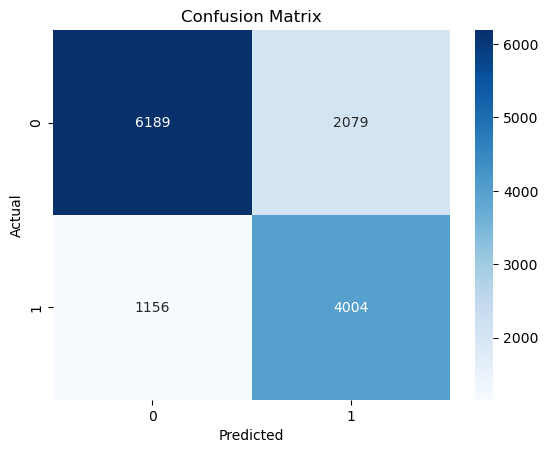


Metrics for Best XGBoost Model with Extra Features - Non-Appalachia
Confusion Matrix:
[[7467 2397]
 [1551 4767]]
Accuracy: 0.7560252131998517


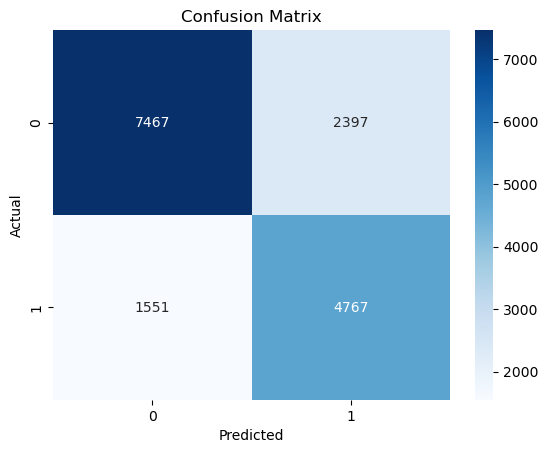

In [28]:
# Evaluate the extra models
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Confusion Matrix:\n{cm}\nAccuracy: {accuracy}')
    
    # Plot confusion matrix heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

print('\nMetrics for Best XGBoost Model with Extra Features - Appalachia')
evaluate_model(best_model_A_extra, test_A_extra, y_test_A_extra)
print('\nMetrics for Best XGBoost Model with Extra Features - Non-Appalachia')
evaluate_model(best_model_NA_extra, test_NA_extra, y_test_NA_extra)

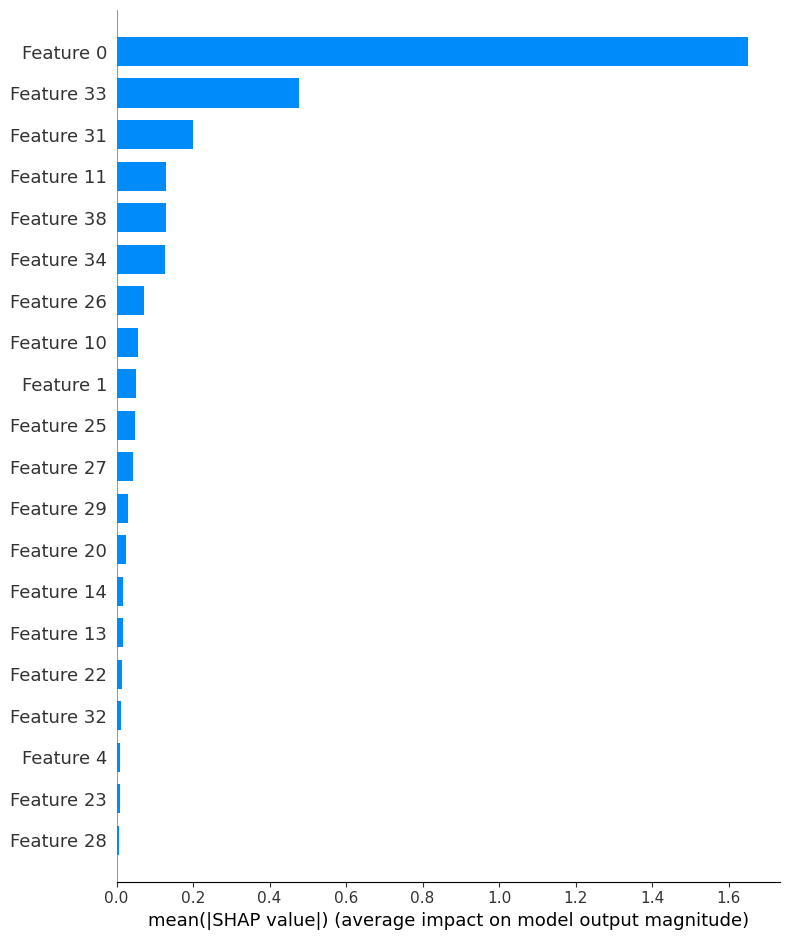

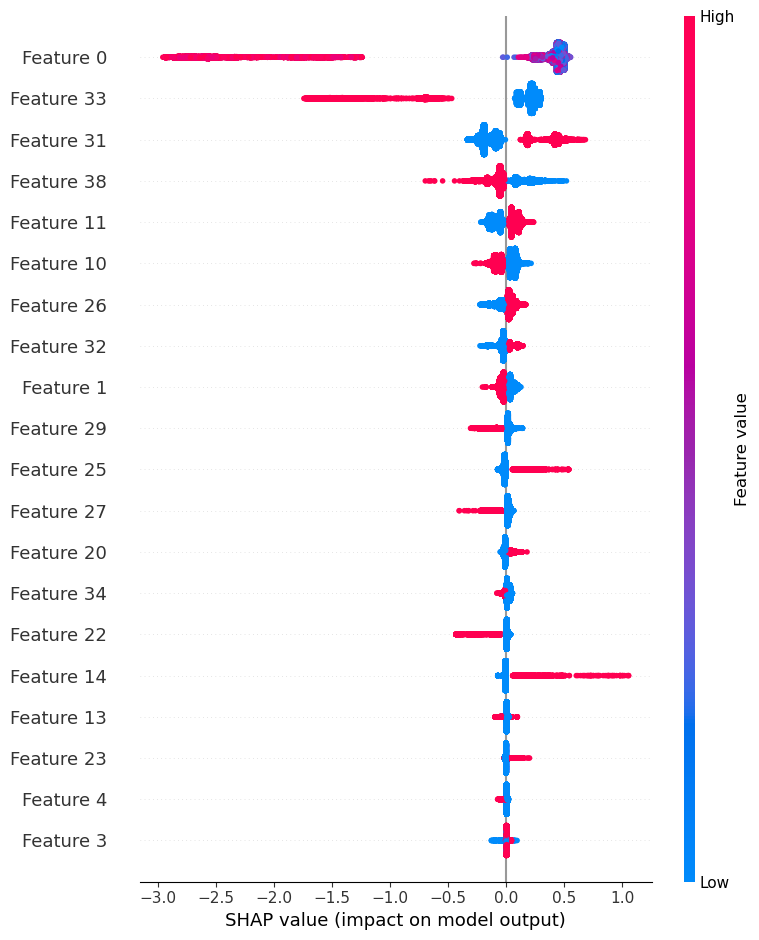

In [29]:
# Plot SHAP values for feature importance with extra features
explainer_A_extra = shap.Explainer(best_model_A_extra)
shap_values_A_extra = explainer_A_extra(train_A_extra)
shap.summary_plot(shap_values_A_extra, train_A_extra, plot_type='bar')

explainer_NA_extra = shap.Explainer(best_model_NA_extra)
shap_values_NA_extra = explainer_NA_extra(train_NA_extra)
shap.summary_plot(shap_values_NA_extra, train_NA_extra)

# Function to calculate Desperate Index
def desperate_index(model, X_test, y_test):
    y_pred = model.predict(X_test)
    bias = sum(abs(y_test - y_pred)) / len(y_test)  # Simplified version of a bias calculation
    return bias

In [30]:
# Calculate Desperate Index for the optimized models with and without extra features
bias_A = desperate_index(best_model_A, test_A, y_test_A)
bias_NA = desperate_index(best_model_NA, test_NA, y_test_NA)
bias_A_extra = desperate_index(best_model_A_extra, test_A_extra, y_test_A_extra)
bias_NA_extra = desperate_index(best_model_NA_extra, test_NA_extra, y_test_NA_extra)

print(f'\nDesperate Index for Optimized Model - Appalachia: {bias_A}')
print(f'Desperate Index for Optimized Model - Non-Appalachia: {bias_NA}')
print(f'Desperate Index for Optimized Model with Extra Features - Appalachia: {bias_A_extra}')
print(f'Desperate Index for Optimized Model with Extra Features - Non-Appalachia: {bias_NA_extra}')


Desperate Index for Optimized Model - Appalachia: 0.21730711945189157
Desperate Index for Optimized Model - Non-Appalachia: 0.21863799283154123
Desperate Index for Optimized Model with Extra Features - Appalachia: 0.24091450700029787
Desperate Index for Optimized Model with Extra Features - Non-Appalachia: 0.2439747868001483


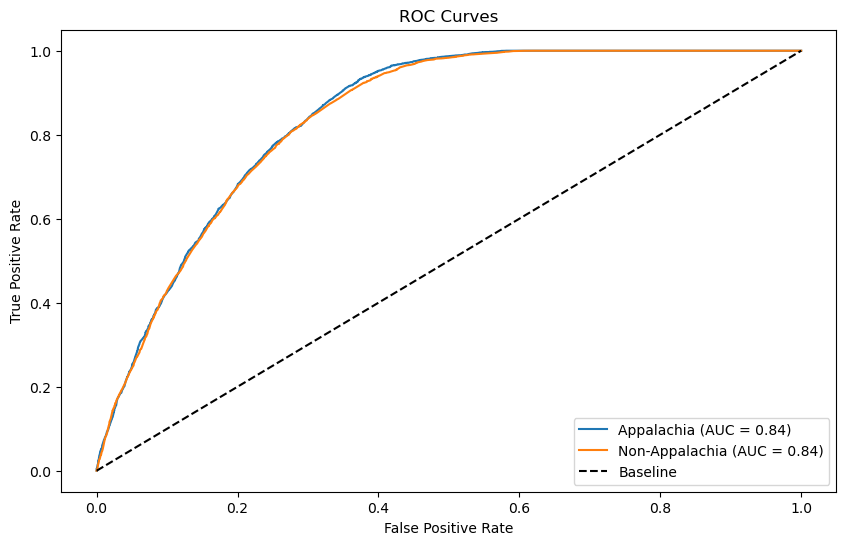

In [31]:
# Plot ROC curves
def plot_roc(model, X_test, y_test, label):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')

plt.figure(figsize=(10, 6))
plot_roc(best_model_A_extra, test_A_extra, y_test_A_extra, 'Appalachia')
plot_roc(best_model_NA_extra, test_NA_extra, y_test_NA_extra, 'Non-Appalachia')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.show()
